Code for Subsection 3.4.1. One-dimensional VaR and CVaR Computation.

**Usage Note**

This notebook uses `rpy2` to load the `danishmulti` dataset from the R package `CASdatasets`. Before running the code, please make sure that a working R environment is installed and properly configured on your system. You also need to install the required R package in R first:

```r
install.packages("CASdatasets")
```

In Python, ensure that `rpy2` is installed:

```bash
pip install rpy2
```

After both R and `CASdatasets` are available, the code will load the R package, import the `danishmulti` dataset, and convert it into a pandas DataFrame for further analysis in Python.

In [4]:
# ============================================================
# Example 3: 1D CVaR on Danish Fire Loss Data
# Experiment 1: Fixed-Time Log-Log RMSE Analysis
# ============================================================

import importlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from matplotlib.ticker import ScalarFormatter

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter

import Algorithms
importlib.reload(Algorithms)
from Algorithms import TamedSGHMC, TUSLA

# ------------------------------
# Load Danish fire loss data from R CASdatasets
# ------------------------------

ro.r('if (!requireNamespace("CASdatasets", quietly = TRUE)) stop("CASdatasets is not installed. Please install it in R first.")')
ro.r("library(CASdatasets)")
ro.r("data(danishmulti)")

with localconverter(default_converter + pandas2ri.converter):
    danishmulti = ro.conversion.rpy2py(ro.r("danishmulti"))

losses = danishmulti["Total"].dropna().to_numpy(dtype=float)
N = len(losses)

print(f"Dataset size: {N}")
print(f"Loss statistics: mean={losses.mean():.4f}, std={losses.std():.4f}, max={losses.max():.4f}")

# ------------------------------
# CVaR setup
# ------------------------------

q = 0.95
eta = 1e-3
inv_tail = 1.0 / (1.0 - q)

m = eta
r = 1.0
beta = 1e10
gamma = 1.0

def _to_float(x):
    return float(np.asarray(x).reshape(-1)[0])

def objective_u(theta):
    th = _to_float(theta)
    return float(th + np.mean(np.maximum(losses - th, 0.0)) / (1.0 - q) + 0.5 * eta * th**2)

def H_cvar(theta, x):
    th, xx = _to_float(theta), _to_float(x)
    grad = -q / (1.0 - q) + eta * th + inv_tail * float(xx < th)
    return float(grad) if np.ndim(theta) == 0 else np.array([grad], dtype=float)

# ------------------------------
# Fixed-time log-log RMSE settings
# ------------------------------

T_end = 10.0
h_min, h_max, n_grid = 1e-4, 1e-3, 8
step_sizes = np.exp(np.linspace(np.log(h_min), np.log(h_max), n_grid))
log_h_vals = np.log(step_sizes)

lr_ref_fixed = 1e-5
n_particles = 100
seed_base = 20260525

def draw_fixed_inputs(rep, n_steps):
    rng_data = np.random.default_rng(300000 + rep)
    rng_theta = np.random.default_rng(310000 + rep)
    theta0 = float(rng_theta.normal(0.0, 1.0))
    xs = losses[rng_data.integers(0, len(losses), size=n_steps)]
    return theta0, xs

def make_solver(alg_name, lr):
    if alg_name == "TUSLA":
        return TUSLA(H=H_cvar, lr=lr, beta=beta, r=r)
    if alg_name == "tSGHMC":
        return TamedSGHMC(H=H_cvar, lr=lr, gamma=gamma, beta=beta, m=m, r=r)
    raise ValueError("alg_name must be 'TUSLA' or 'tSGHMC'.")

def run_fixed_time(alg_name, lr, T, n_particles):
    n_steps = int(np.ceil(T / lr))
    terminals = np.zeros(n_particles, dtype=float)

    for rep in range(n_particles):
        theta, xs = draw_fixed_inputs(rep, n_steps)
        solver = make_solver(alg_name, lr)
        rng_alg = np.random.default_rng(320000 + rep if alg_name == "tSGHMC" else 330000 + rep)

        if alg_name == "TUSLA":
            for x in xs:
                theta = solver.step(theta, x, rng=rng_alg)
        else:
            vol = 0.0
            for x in xs:
                theta, vol = solver.step(theta, vol, x, rng=rng_alg)

        terminals[rep] = float(theta)

    return terminals

def empirical_rmse(terminals, ref_terminals):
    terminals = np.asarray(terminals, dtype=float)
    ref_terminals = np.asarray(ref_terminals, dtype=float)
    return float(np.sqrt(np.mean((terminals - ref_terminals) ** 2)))

# ------------------------------
# Run fixed-time RMSE experiment
# ------------------------------

print("\nComputing fixed-time reference solutions...")
theta_ref_tamed = run_fixed_time("tSGHMC", lr_ref_fixed, T_end, n_particles)
theta_ref_tusla = run_fixed_time("TUSLA", lr_ref_fixed, T_end, n_particles)

print(f"  tSGHMC reference mean: {np.mean(theta_ref_tamed):.8f}")
print(f"  TUSLA reference mean:  {np.mean(theta_ref_tusla):.8f}")

rmse_tamed_list, rmse_tusla_list = [], []

print("\nSweeping step sizes...")
for lr_test in step_sizes:
    n_steps_test = int(np.ceil(T_end / lr_test))
    print(f"  h={lr_test:.2e}, n_steps={n_steps_test} ...", end=" ")

    theta_tamed = run_fixed_time("tSGHMC", lr_test, T_end, n_particles)
    theta_tusla = run_fixed_time("TUSLA", lr_test, T_end, n_particles)

    rmse_tamed = empirical_rmse(theta_tamed, theta_ref_tamed)
    rmse_tusla = empirical_rmse(theta_tusla, theta_ref_tusla)

    rmse_tamed_list.append(rmse_tamed)
    rmse_tusla_list.append(rmse_tusla)

    print(f"RMSE: tSGHMC={rmse_tamed:.6e}, TUSLA={rmse_tusla:.6e}")

rmse_tamed = np.asarray(rmse_tamed_list, dtype=float)
rmse_tusla = np.asarray(rmse_tusla_list, dtype=float)

log_rmse_tamed = np.log(np.maximum(rmse_tamed, 1e-12))
log_rmse_tusla = np.log(np.maximum(rmse_tusla, 1e-12))

slope_tamed, intercept_tamed = np.polyfit(log_h_vals, log_rmse_tamed, deg=1)
slope_tusla, intercept_tusla = np.polyfit(log_h_vals, log_rmse_tusla, deg=1)

print("\n" + "=" * 60)
print("FIXED-TIME LOG-LOG ANALYSIS SUMMARY")
print("=" * 60)
print(f"Physical time T:      {T_end}")
print(f"Reference step size:  {lr_ref_fixed:.2e}")
print(f"Number of particles: {n_particles}")
print("\nConvergence rates:")
print(f"  tSGHMC: {slope_tamed:.6f}")
print(f"  TUSLA:  {slope_tusla:.6f}")
print(f"\nFinal errors at h_max={step_sizes[-1]:.2e}:")
print(f"  tSGHMC RMSE: {rmse_tamed[-1]:.8e}")
print(f"  TUSLA RMSE:  {rmse_tusla[-1]:.8e}")

Dataset size: 2167
Loss statistics: mean=3.3851, std=8.5055, max=263.2504

Computing fixed-time reference solutions...
  tSGHMC reference mean: 7.33413321
  TUSLA reference mean:  8.24377648

Sweeping step sizes...
  h=1.00e-04, n_steps=100000 ... RMSE: tSGHMC=1.491872e-02, TUSLA=3.284214e-01
  h=1.39e-04, n_steps=71969 ... RMSE: tSGHMC=1.693490e-02, TUSLA=4.055460e-01
  h=1.93e-04, n_steps=51795 ... RMSE: tSGHMC=2.159933e-02, TUSLA=4.721557e-01
  h=2.68e-04, n_steps=37276 ... RMSE: tSGHMC=2.148917e-02, TUSLA=5.551234e-01
  h=3.73e-04, n_steps=26827 ... RMSE: tSGHMC=2.438596e-02, TUSLA=6.481939e-01
  h=5.18e-04, n_steps=19307 ... RMSE: tSGHMC=3.051617e-02, TUSLA=7.559323e-01
  h=7.20e-04, n_steps=13895 ... RMSE: tSGHMC=4.059811e-02, TUSLA=8.571161e-01
  h=1.00e-03, n_steps=10000 ... RMSE: tSGHMC=4.676608e-02, TUSLA=9.610016e-01

FIXED-TIME LOG-LOG ANALYSIS SUMMARY
Physical time T:      10.0
Reference step size:  1.00e-05
Number of particles: 100

Convergence rates:
  tSGHMC: 0.489767
 

1D CVaR theoretical minimizer
  theta*    = 9.88286995
  u(theta*) = 24.21579173

1D CVaR expected excess risk study
  step size:            5.00e-03
  iterations:           2000
  repeats:              30
  initial risk, TUSLA:  4.491905e+01
  final risk, TUSLA:    6.343630e-01
  initial risk, tSGHMC: 4.491905e+01
  final risk, tSGHMC:   5.235462e-01


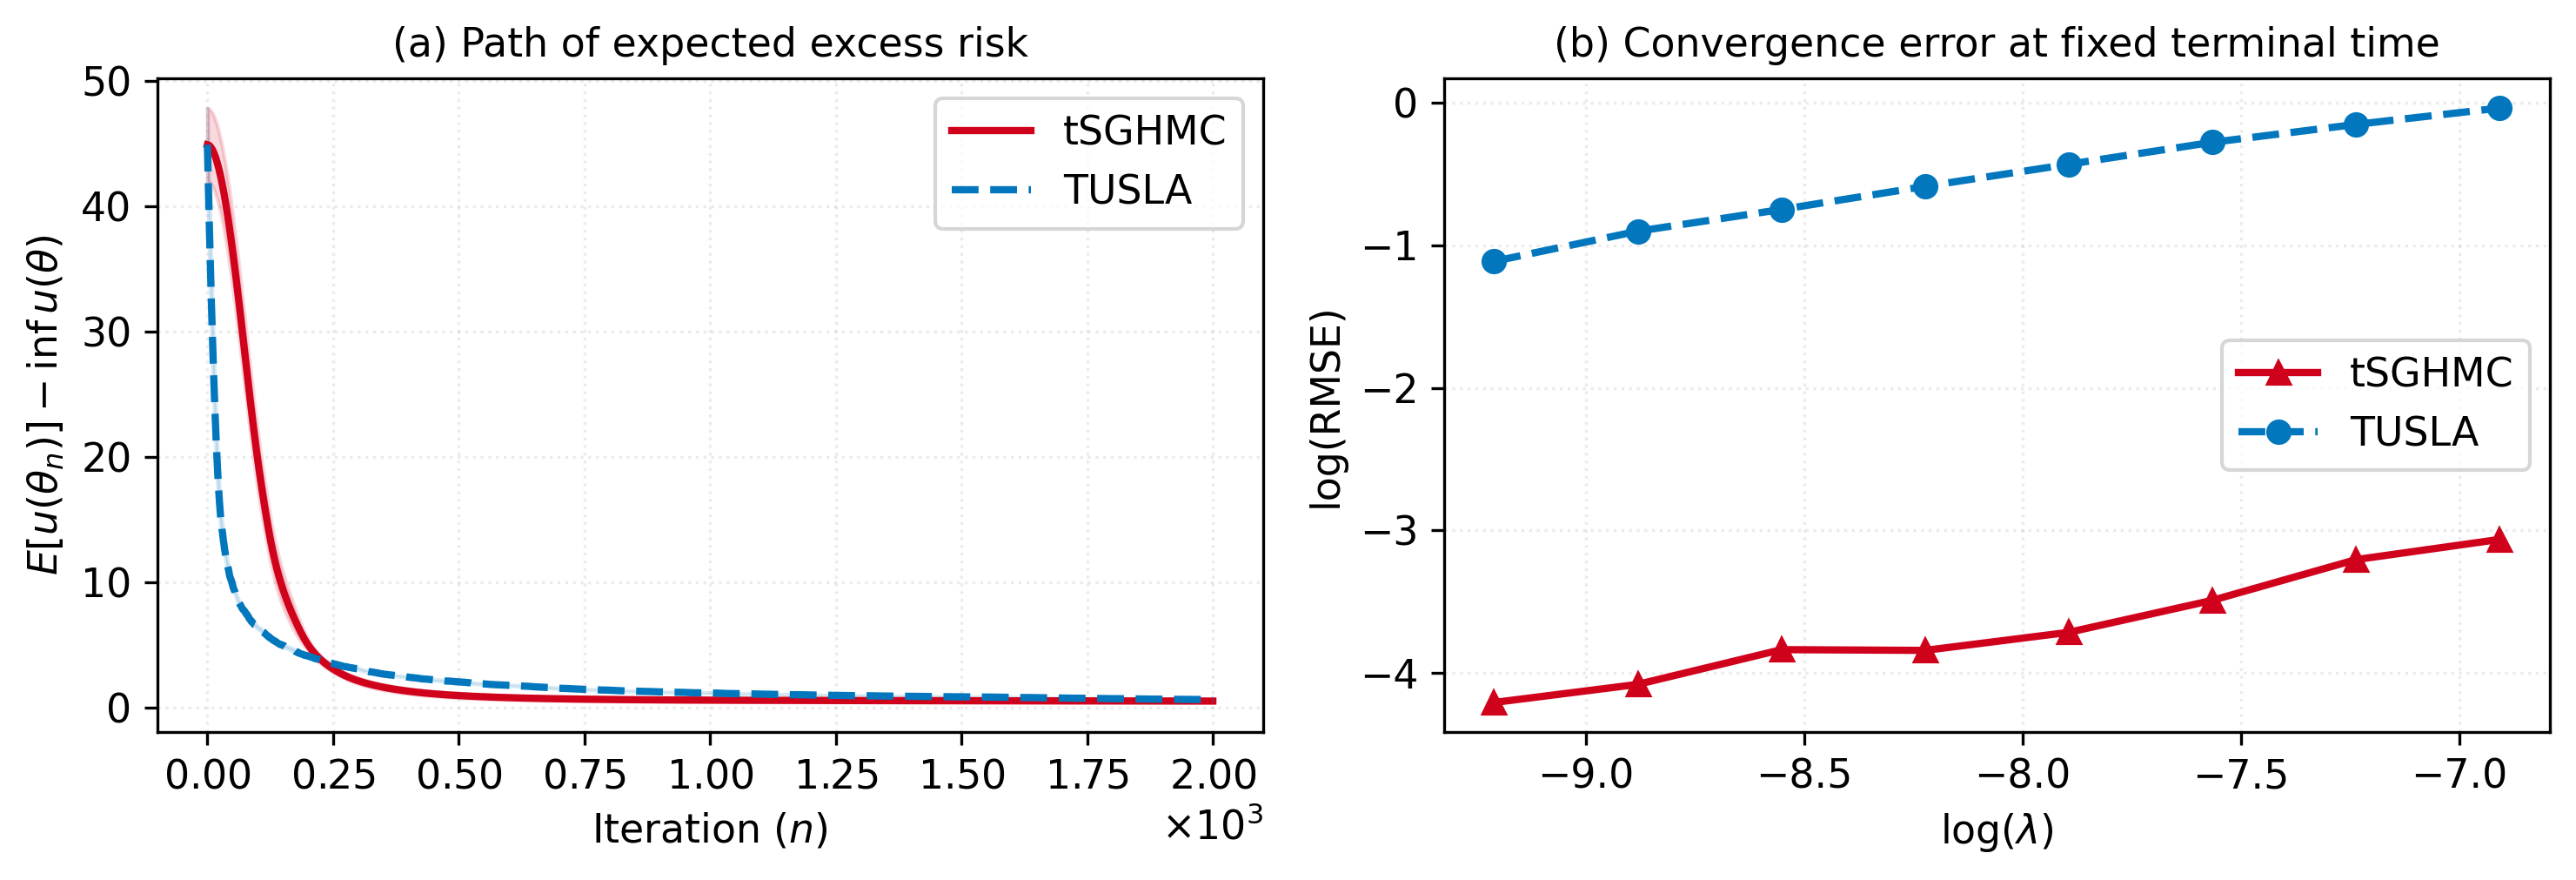

In [5]:
# ============================================================
# Experiment 2: scipy.optimize theoretical minimizer
# Combined plot:
#   Left  - expected excess risk path
#   Right - fixed-time log-log RMSE from Cell 1
# ============================================================

# ------------------------------
# Theoretical minimizer
# ------------------------------

opt_res = minimize_scalar(objective_u, method="brent")
theta_star = float(opt_res.x)
u_star = float(opt_res.fun)

print("1D CVaR theoretical minimizer")
print(f"  theta*    = {theta_star:.8f}")
print(f"  u(theta*) = {u_star:.8f}")

# ------------------------------
# Expected excess risk path settings
# ------------------------------

lr_path = 5e-3
n_steps_path = 2000
n_repeats_path = 30
seed_path = 20260525

def draw_path_inputs(rep):
    rng_data = np.random.default_rng(seed_path + rep)
    theta0 = np.array([rng_data.normal(0.0, 1.0)], dtype=float)
    xs = losses[rng_data.integers(0, len(losses), size=n_steps_path)].reshape(-1, 1)
    return theta0, xs

def simulate_path_once(rep):
    theta0, xs = draw_path_inputs(rep)
    rng_tusla = np.random.default_rng(300000 + rep)
    rng_tamed = np.random.default_rng(400000 + rep)

    solver_tusla = TUSLA(H=H_cvar, lr=lr_path, beta=beta, r=r)
    path_tusla = solver_tusla.simulate(theta0=theta0, xs=xs, n_steps=n_steps_path, rng=rng_tusla).reshape(-1)

    solver_tamed = TamedSGHMC(H=H_cvar, lr=lr_path, gamma=gamma, beta=beta, m=m, r=r)
    path_tamed, _ = solver_tamed.simulate(theta0=theta0, vol0=np.array([0.0], dtype=float), xs=xs, n_steps=n_steps_path, rng=rng_tamed)
    path_tamed = path_tamed.reshape(-1)

    excess_tusla = np.asarray([objective_u(th) - u_star for th in path_tusla], dtype=float)
    excess_tamed = np.asarray([objective_u(th) - u_star for th in path_tamed], dtype=float)

    return excess_tusla, excess_tamed

# ------------------------------
# Run expected excess risk experiment
# ------------------------------

all_excess_tusla, all_excess_tamed = [], []

for rep in range(n_repeats_path):
    excess_tusla_rep, excess_tamed_rep = simulate_path_once(rep)
    all_excess_tusla.append(excess_tusla_rep)
    all_excess_tamed.append(excess_tamed_rep)

excess_tusla_mat = np.stack(all_excess_tusla, axis=0)
excess_tamed_mat = np.stack(all_excess_tamed, axis=0)

mean_tusla = excess_tusla_mat.mean(axis=0)
mean_tamed = excess_tamed_mat.mean(axis=0)

std_tusla = excess_tusla_mat.std(axis=0, ddof=1)
std_tamed = excess_tamed_mat.std(axis=0, ddof=1)

se_tusla = std_tusla / np.sqrt(n_repeats_path)
se_tamed = std_tamed / np.sqrt(n_repeats_path)

iterations = np.arange(n_steps_path + 1)

print("\n1D CVaR expected excess risk study")
print(f"  step size:            {lr_path:.2e}")
print(f"  iterations:           {n_steps_path}")
print(f"  repeats:              {n_repeats_path}")
print(f"  initial risk, TUSLA:  {mean_tusla[0]:.6e}")
print(f"  final risk, TUSLA:    {mean_tusla[-1]:.6e}")
print(f"  initial risk, tSGHMC: {mean_tamed[0]:.6e}")
print(f"  final risk, tSGHMC:   {mean_tamed[-1]:.6e}")

# ------------------------------
# Combined plot
# ------------------------------

plt.rcParams.update({"font.size": 11, "axes.labelsize": 11, "axes.titlesize": 11, "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11})

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=300)

# Left panel: expected excess risk
ax = axes[0]

mean_tamed_plot = np.maximum(mean_tamed, 1e-300)
mean_tusla_plot = np.maximum(mean_tusla, 1e-300)

ax.plot(iterations, mean_tamed_plot, color="#d0021b", linewidth=2.0, label="tSGHMC", zorder=3)
ax.fill_between(iterations, np.maximum(mean_tamed_plot - se_tamed, 1e-300), np.maximum(mean_tamed_plot + se_tamed, 1e-300), color="#d0021b", alpha=0.15, zorder=2)

ax.plot(iterations, mean_tusla_plot, color="#0277bd", linestyle="--", linewidth=2.0, label="TUSLA", zorder=3)
ax.fill_between(iterations, np.maximum(mean_tusla_plot - se_tusla, 1e-300), np.maximum(mean_tusla_plot + se_tusla, 1e-300), color="#0277bd", alpha=0.15, zorder=1)

ax.set_xlabel(r"Iteration $(n)$")
ax.set_ylabel(r"$E[u(\theta_n)]-\inf u(\theta)$")
ax.set_title("(a) Path of expected excess risk")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True)

sf_iter = ScalarFormatter(useMathText=True)
sf_iter.set_scientific(True)
sf_iter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(sf_iter)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

# Right panel: fixed-time log-log RMSE
ax = axes[1]

ax.plot(log_h_vals, log_rmse_tamed, color="#d0021b", marker="^", linewidth=2.0, markersize=6.0, label="tSGHMC")
ax.plot(log_h_vals, log_rmse_tusla, color="#0277bd", marker="o", linestyle="--", linewidth=2.0, markersize=6.0, label="TUSLA")

ax.set_xlabel(r"$\log(\lambda)$")
ax.set_ylabel("log(RMSE)")
ax.set_title("(b) Convergence error at fixed terminal time")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True, loc="best")

fig.tight_layout()
plt.show()

fig.savefig("Example4_CVaR_1D_combined.png", dpi=220, bbox_inches="tight")